https://www.kaggle.com/c/bike-sharing-demand/data?select=train.csv

# 자전거 대여량 예측 모델

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

In [ ]:
bike_df = pd.read_csv('../data/train.csv')
bike_df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [3]:
bike_df1 = bike_df.drop('datetime', axis=1)
bike_df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      10886 non-null  int64  
 1   holiday     10886 non-null  int64  
 2   workingday  10886 non-null  int64  
 3   weather     10886 non-null  int64  
 4   temp        10886 non-null  float64
 5   atemp       10886 non-null  float64
 6   humidity    10886 non-null  int64  
 7   windspeed   10886 non-null  float64
 8   casual      10886 non-null  int64  
 9   registered  10886 non-null  int64  
 10  count       10886 non-null  int64  
dtypes: float64(3), int64(8)
memory usage: 935.6 KB


In [4]:
X = bike_df1.drop('count', axis=1).values
y = bike_df1['count'].values
bike_df1.shape

(10886, 11)

## 모델 만들기 (선형회귀)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=156)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
y_pred[:3]

array([ 21., 626.,  54.])

In [6]:
# 평가
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
rmse, mse

(np.float64(3.2267789232019346e-13), np.float64(1.0412102219220236e-25))

+ RMSE는 약 3.23이다

In [7]:
# 결정계수
r2_score(y_test, y_pred)

np.float64(1.0)

+ 결정계수 R2스코어는 1.0이다

In [8]:
# 회귀식
# w0, w1
lr.intercept_, lr.coef_

(np.float64(3.979039320256561e-13),
 array([-4.93153483e-15, -2.61059469e-13, -2.07296690e-14, -2.59410976e-14,
        -6.01241104e-15,  3.32270922e-15,  3.48793235e-16,  1.93173241e-16,
         1.00000000e+00,  1.00000000e+00]))

In [9]:
np.round(lr.intercept_, 1), np.round(lr.coef_, 1)

(np.float64(0.0), array([-0., -0., -0., -0., -0.,  0.,  0.,  0.,  1.,  1.]))

In [10]:
pd.Series(data=np.round(lr.coef_, 1), index=bike_df1.drop('count', axis=1).columns).sort_values(ascending=False)

registered    1.0
casual        1.0
holiday      -0.0
season       -0.0
workingday   -0.0
weather      -0.0
atemp         0.0
temp         -0.0
windspeed     0.0
humidity      0.0
dtype: float64

## 모델 만들기 (랜덤포레스트)

In [11]:
from sklearn.ensemble import RandomForestRegressor

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=156)
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_pred[:3]

array([ 20.81, 623.46,  55.44])

In [13]:
# 평가
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
rmse, mse

(np.float64(3.2793760234975355), np.float64(10.754307103490508))

+ RMSE는 약 3.18이다

In [14]:
# 결정계수
r2_score(y_test, y_pred)

np.float64(0.9996658396236024)

+ 결정계수 R2스코어는 약 1.0이다

In [15]:
# 피처 중요도 확인
feature_importances = rf.feature_importances_
feature_names = bike_df1.drop('count', axis=1).columns

# 각 피처의 이름과 중요도를 매칭하여 출력
for feature, importance in zip(feature_names, feature_importances):
    print(f"{feature}: {importance:.4f}")

season: 0.0000
holiday: 0.0000
workingday: 0.0000
weather: 0.0000
temp: 0.0001
atemp: 0.0001
humidity: 0.0001
windspeed: 0.0001
casual: 0.0474
registered: 0.9523


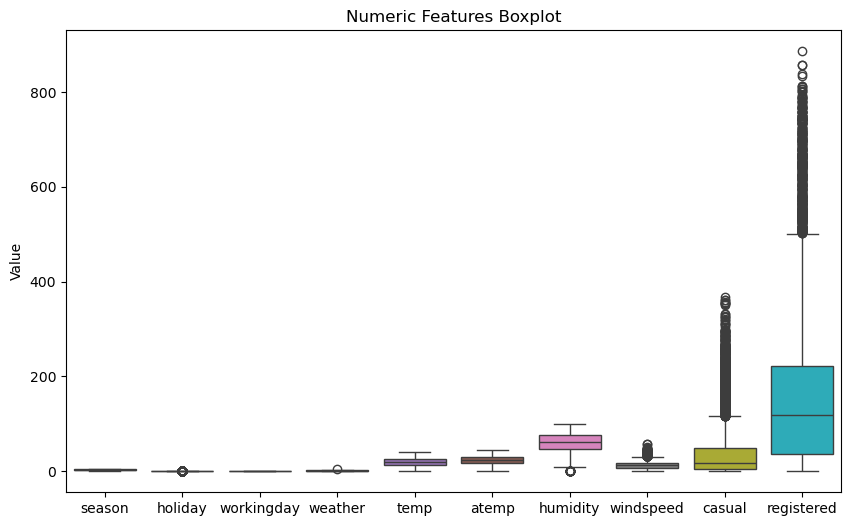

In [16]:
import seaborn as sns
numeric_cols = ['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered']
numeric_df = bike_df1[numeric_cols]

plt.figure(figsize=(10, 6)) # 플롯 크기 설정
sns.boxplot(data=numeric_df) # x나 y를 지정하지 않고, 수치형 DataFrame 전달
plt.title('Numeric Features Boxplot')
plt.ylabel('Value')
plt.show()

+ 위 그래프 결과 'windspeed', 'casual', 'registered'컬럼에 이상치가 많음을 알 수 있다

<Axes: >

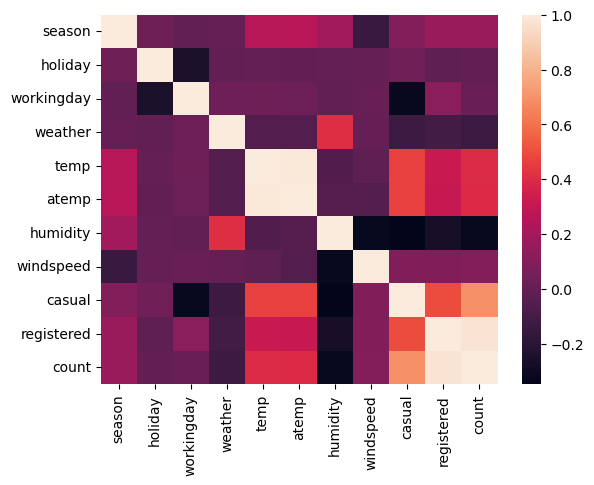

In [17]:
sns.heatmap(bike_df1.corr())

+ 위 히트맵 결과 예측하고자 하는 y값('count')과 가장 상관관계가 높은 것은 'registered'임을 알 수 있다   
+ 위 히트맵 결과 예측하고자 하는 y값('count')과 가장 상관관계가 낮은 것은 'humidity'임을 알 수 있다   

+ 비회원 대여 수와 회원 대여 수를 더한 것이 count 이다   

#### 그러므로 습도(humidity)를 제외 + 비회원 대여 수(casual) 제외 + 회원 대여 수(registered) 제외한 모델을 다시 생성하도록 한다

### 모델 만들기 (선형회귀) - humidity, casual, registered 제외

In [41]:
bike_df2 = bike_df1.drop(['humidity', 'casual', 'registered'], axis=1)
bike_df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      10886 non-null  int64  
 1   holiday     10886 non-null  int64  
 2   workingday  10886 non-null  int64  
 3   weather     10886 non-null  int64  
 4   temp        10886 non-null  float64
 5   atemp       10886 non-null  float64
 6   windspeed   10886 non-null  float64
 7   count       10886 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 680.5 KB


In [42]:
X = bike_df2.drop('count', axis=1).values
y = bike_df2['count'].values
bike_df2.shape

(10886, 8)

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=156)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
y_pred[:3]

array([ 58.88648059, 255.11148545,  50.7115701 ])

In [44]:
# 평가
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
rmse, mse

(np.float64(159.38406371385895), np.float64(25403.27976594345))

+ RMSE는 약 159.38이다

In [45]:
# 결정계수
r2_score(y_test, y_pred)

np.float64(0.2106632768964365)

+ 결정계수 R2스코어는 0.21이다

In [46]:
# 회귀식
# w0, w1
lr.intercept_, lr.coef_

(np.float64(-13.517654370322958),
 array([ 14.66015298,  -4.76361875,   2.36890415, -30.15767802,
          4.50463608,   3.57673319,   2.7125149 ]))

In [47]:
np.round(lr.intercept_, 1), np.round(lr.coef_, 1)

(np.float64(-13.5), array([ 14.7,  -4.8,   2.4, -30.2,   4.5,   3.6,   2.7]))

In [48]:
pd.Series(data=np.round(lr.coef_, 1), index=bike_df2.drop('count', axis=1).columns).sort_values(ascending=False)

season        14.7
temp           4.5
atemp          3.6
windspeed      2.7
workingday     2.4
holiday       -4.8
weather      -30.2
dtype: float64

### 모델 만들기 (랜덤포레스트) - humidity, casual, registered 제외

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=156)
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_pred[:3]

array([ 67.56366667, 549.59333333,  89.00032359])

In [50]:
# 평가
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
rmse, mse

(np.float64(163.0537141161049), np.float64(26586.51368705647))

+ RMSE는 약 163.05이다

In [51]:
# 결정계수
r2_score(y_test, y_pred)

np.float64(0.17389755236946236)

+ 결정계수 R2스코어는 약 0.17이다

In [52]:
# 피처 중요도 확인
feature_importances = rf.feature_importances_
feature_names = bike_df2.drop('count', axis=1).columns

# 각 피처의 이름과 중요도를 매칭하여 출력
for feature, importance in zip(feature_names, feature_importances):
    print(f"{feature}: {importance:.4f}")

season: 0.0864
holiday: 0.0110
workingday: 0.0597
weather: 0.0805
temp: 0.2092
atemp: 0.3029
windspeed: 0.2504


#### 2차~5차 다항회귀 시뮬레이션 (LineareRegressor)

In [53]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=156)
model_poly = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('linear', LinearRegression())]
)
model_poly.fit(X_train, y_train)

Pipeline(steps=[('poly', PolynomialFeatures(include_bias=False)),
                ('linear', LinearRegression())])

In [55]:
pred_poly = model_poly.predict(X_test)
mean_squared_error(y_test, pred_poly)

np.float64(24456.011238297207)

In [56]:
r2_score(y_test, pred_poly)

np.float64(0.24009702885289985)

In [63]:
results = []
best_r2=-np.inf
best_model = None
best_pred = None

for degree in range(1,6):
    model_poly = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('linear', LinearRegression())]
    )
    model_poly.fit(X_train, y_train)
    pred_poly = model_poly.predict(X_test)
    mse = mean_squared_error(y_test, pred_poly)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred_poly)
    results.append({'degree':degree, 'MSE':mse, 'RMSE':rmse, 'R2':r2})
    if r2 > best_r2:
        best_r2 = r2
        best_model = model_poly
        best_pred = pred_poly    
    
pd.DataFrame(results)

,degree,MSE,RMSE,R2
0,1,25403.279766,159.384064,0.210663
1,2,24456.011238,156.384178,0.240097
2,3,23469.225552,153.196689,0.270759
3,4,23428.164121,153.062615,0.272035
4,5,57689.876351,240.187169,-0.792553


#### Lineare Regressor를 사용하였을 때 다항회귀 결과   
+ 결과를 보니 R2스코어가 5차에서 갑자기 값이 떨어져서 이 모델은 **4차**까지 사용할 때 성능이 좋다
+ 결과를 보니 RMSE가 5차에서 갑자기 값이 커져서 이 모델은 **4차**까지 사용할 때 성능이 좋다

#### 2차~5차 다항회귀 시뮬레이션 (RandomForest)

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=156)
model_poly = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('RandomForest', RandomForestRegressor())]
)
model_poly.fit(X_train, y_train)

Pipeline(steps=[('poly', PolynomialFeatures(include_bias=False)),
                ('RandomForest', RandomForestRegressor())])

In [59]:
pred_poly = model_poly.predict(X_test)
mean_squared_error(y_test, pred_poly)

np.float64(26682.11244261712)

In [60]:
r2_score(y_test, pred_poly)

np.float64(0.17092708520371536)

In [66]:
results = []
best_r2=-np.inf
best_model = None
best_pred = None

for degree in range(1,7):
    model_poly = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('RandomForest', RandomForestRegressor())]
    )
    model_poly.fit(X_train, y_train)
    pred_poly = model_poly.predict(X_test)
    mse = mean_squared_error(y_test, pred_poly)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred_poly)
    results.append({'degree':degree, 'MSE':mse, 'RMSE':rmse, 'R2':r2})
    if r2 > best_r2:
        best_r2 = r2
        best_model = model_poly
        best_pred = pred_poly
    
pd.DataFrame(results)

,degree,MSE,RMSE,R2
0,1,26803.857930,163.718838,0.167144
1,2,26562.093009,162.978812,0.174656
2,3,26769.389567,163.613537,0.168215
3,4,26503.710195,162.799601,0.176470
4,5,26495.491527,162.774358,0.176726
5,6,26628.842936,163.183464,0.172582


#### RandomForest Regressor를 사용하였을 때 다항회귀 결과   
+ 결과를 보니 R2스코어가 5차에서 가장 높으므로 이 모델은 **5차**까지 사용할 때 성능이 좋다

# 규제 회귀 모델

In [67]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

## Ridge

In [68]:
ridge = Ridge(alpha=1.0)   # 규제 강도
ridge.fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)

mse = mean_squared_error(y_test, pred_ridge)
r2  = r2_score(y_test, pred_ridge)
mse, r2

(np.float64(25403.32194446384), np.float64(0.2106619663154652))

+ alpha가 1일 때 r2는 약 0.21

In [69]:
from sklearn.linear_model import RidgeCV, LassoCV
alphas = [0.001, 0.01,0.1, 1, 10, 100]
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train, y_train)
ridge_preds = ridge_cv.predict(X_test)
ridge_mse = mean_squared_error(y_test, ridge_preds)
ridge_r2 = r2_score(y_test, ridge_preds)

print(f'ridge cv mse : {ridge_mse}, r2 : {ridge_r2}')

ridge cv mse : 25407.278013556403, r2 : 0.2105390424000234


In [70]:
ridge_cv.alpha_   # 최적의 알파값

np.float64(100.0)

+ 이 모델은 Ridge함수 사용 시 alphas중 값이 100일 때가 가장 좋다

In [71]:
ridge_cv.coef_

array([ 14.46307931,  -3.19569141,   2.3162885 , -29.18784804,
         4.49343201,   3.59668928,   2.70858073])

## Lasso

In [72]:
lasso = Lasso(alpha=1)   # 규제 강도
lasso.fit(X_train, y_train)
pred_lasso = lasso.predict(X_test)

mse = mean_squared_error(y_test, pred_lasso)
r2 = r2_score(y_test, pred_lasso)
mse, r2

(np.float64(25414.867553630622), np.float64(0.21030321841401656))

+ alpha가 1일 때 r2는 약 0.21

In [73]:
from sklearn.linear_model import RidgeCV, LassoCV
alphas = [0.001, 0.01,0.1, 1, 10, 100]
lasso_cv = LassoCV(alphas=alphas, cv=5)
lasso_cv.fit(X_train, y_train)
lasso_preds = lasso_cv.predict(X_test)
lasso_mse = mean_squared_error(y_test, lasso_preds)
lasso_r2 = r2_score(y_test, lasso_preds)
print(f'lasso cv mse : {lasso_mse}, r2 : {lasso_r2}')

lasso cv mse : 25414.867553630622, r2 : 0.21030321841401656


In [74]:
lasso_cv.alpha_   # 최적의 알파값

np.float64(1.0)

+ 이 모델은 Lasso함수 사용 시 alphas중 값이 1일 때가 가장 좋다

In [75]:
lasso_cv.coef_

array([ 13.69560449,  -0.        ,   0.        , -27.54528416,
         4.59790163,   3.52486558,   2.678922  ])

## 엘라스틱넷

In [76]:
enet = ElasticNet(alpha=0.1, l1_ratio=0.5)
enet.fit(X_train, y_train)

ElasticNet(alpha=0.1)

In [77]:
pred_enet = enet.predict(X_test)
print("엘라스틱넷 회귀")
print(f"MSE : {mean_squared_error(y_test, pred_enet)}")
print(f"R2 : {r2_score(y_test, pred_enet)}")

엘라스틱넷 회귀
MSE : 25420.123446249294
R2 : 0.21013990607423882


# 모델 성능 비교

In [78]:
results = pd.DataFrame({
    '모델':['다항회귀', '릿지회귀', '라쏘회귀', '엘라스틱넷회귀'],
    'MSE' : [mean_squared_error(y_test, pred_poly),
             mean_squared_error(y_test, pred_ridge),
             mean_squared_error(y_test, pred_lasso),
             mean_squared_error(y_test, pred_enet)],
    'R2' : [r2_score(y_test, best_pred),
            r2_score(y_test, pred_ridge),
            r2_score(y_test, pred_lasso),
            r2_score(y_test, pred_enet)]
})
results

,모델,MSE,R2
0,다항회귀,26628.842936,0.176726
1,릿지회귀,25403.321944,0.210662
2,라쏘회귀,25414.867554,0.210303
3,엘라스틱넷회귀,25420.123446,0.210140


+ 모델 성능 비교 결과 **R2 기준 릿지회귀**가 가장 좋다
+ 모델 성능 비교 결과 **MSE 기준 릿지회귀**가 가장 좋다

# LinearRegression 스케일링 

In [96]:
# 스케일링
from sklearn.preprocessing import StandardScaler
scaler1 = StandardScaler()
scaler1.fit(X_train)
X_train_scaled = scaler1.transform(X_train)
X_test_scaled = scaler1.transform(X_test)

In [97]:
scaling_model = LinearRegression()
scaling_model.fit(X_train_scaled, y_train)

LinearRegression()

In [98]:
pred_scaled = scaling_model.predict(X_test_scaled)

In [116]:
results_scaled = []
best_r2_scaled=-np.inf
best_model_scaled = None
best_pred_scaled = None

for degree in range(1,5):
    model_poly_scaled = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('linear', LinearRegression())]
    )
    model_poly_scaled.fit(X_train_scaled, y_train)
    pred_poly_scaled = model_poly_scaled.predict(X_test_scaled)
    mse_scaled = mean_squared_error(y_test, pred_poly_scaled)
    rmse_scaled = np.sqrt(mse_scaled)
    r2_scaled = r2_score(y_test, pred_poly_scaled)
    results_scaled.append({'degree':degree, 'MSE':mse_scaled, 'RMSE':rmse_scaled, 'R2':r2_scaled})
    if r2_scaled > best_r2_scaled:
        best_r2_scaled = r2_scaled
        best_model_scaled = model_poly_scaled
        best_pred_scaled = pred_poly_scaled    
    
pd.DataFrame(results_scaled)

,degree,MSE,RMSE,R2
0,1,25403.279766,159.384064,0.210663
1,2,24455.711439,156.383220,0.240106
2,3,23469.171402,153.196512,0.270760
3,4,24470.897911,156.431768,0.239634


#### Linear Regressor를 스케일링 후 사용하였을 때 다항회귀 결과   
+ 결과를 보니 R2스코어가 3차에서 가장 높으므로 이 모델은 **3차**까지 사용할 때 성능이 좋다
+ 결과를 보니 RMSE가 3차에서 가장 낮으므로 이 모델은 **3차**까지 사용할 때 성능이 좋다

## 스케일링 후 규제 회귀 모델

In [100]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

### Ridge

In [117]:
ridge_scaled = Ridge(alpha=1.0)   # 규제 강도
ridge_scaled.fit(X_train_scaled, y_train)
pred_ridge_scaled = ridge_scaled.predict(X_test_scaled)

mse = mean_squared_error(y_test, pred_ridge_scaled)
r2  = r2_score(y_test, pred_ridge_scaled)
mse, r2

(np.float64(25403.35241899083), np.float64(0.2106610194037477))

+ alpha가 1일 때 r2는 약 0.21

In [118]:
from sklearn.linear_model import RidgeCV, LassoCV
alphas = [0.001, 0.01,0.1, 1, 10, 100]
ridge_cv_scaled = RidgeCV(alphas=alphas, cv=5)
ridge_cv_scaled.fit(X_train_scaled, y_train)
ridge_preds_scaled = ridge_cv_scaled.predict(X_test_scaled)
ridge_mse_scaled = mean_squared_error(y_test, ridge_preds_scaled)
ridge_r2_scaled = r2_score(y_test, ridge_preds_scaled)

print(f'ridge cv mse : {ridge_mse_scaled}, r2 : {ridge_r2_scaled}')

ridge cv mse : 25411.09213994556, r2 : 0.2104205289618667


In [119]:
ridge_cv_scaled.alpha_   # 최적의 알파값

np.float64(100.0)

+ 이 모델은 스케일링 후 Ridge함수 사용 시 alphas중 값이 100일 때가 가장 좋다

In [120]:
ridge_cv_scaled.coef_

array([ 16.2298728 ,  -0.7570453 ,   1.10974055, -18.88001137,
        34.00583345,  31.17049325,  21.86005274])

### Lasso

In [121]:
lasso_scaled = Lasso(alpha=1)   # 규제 강도
lasso_scaled.fit(X_train_scaled, y_train)
pred_lasso_scaled = lasso.predict(X_test_scaled)

mse = mean_squared_error(y_test, pred_lasso_scaled)
r2 = r2_score(y_test, pred_lasso_scaled)
mse, r2

(np.float64(25429.227936963685), np.float64(0.20985700918327677))

+ alpha가 1일 때 r2는 약 0.21

In [122]:
from sklearn.linear_model import RidgeCV, LassoCV
alphas = [0.001, 0.01,0.1, 1, 10, 100]
lasso_cv_scaled = LassoCV(alphas=alphas, cv=5)
lasso_cv_scaled.fit(X_train_scaled, y_train)
lasso_preds_scaled = lasso_cv_scaled.predict(X_test_scaled)
lasso_mse_scaled = mean_squared_error(y_test, lasso_preds_scaled)
lasso_r2_scaled = r2_score(y_test, lasso_preds_scaled)
print(f'lasso cv mse : {lasso_mse_scaled}, r2 : {lasso_r2_scaled}')

lasso cv mse : 25429.227936963685, r2 : 0.20985700918327677


In [123]:
lasso_cv_scaled.alpha_   # 최적의 알파값

np.float64(1.0)

+ 이 모델은 스케일링 후 Lasso함수 사용 시 alphas중 값이 1일 때가 가장 좋다

In [124]:
lasso_cv_scaled.coef_

array([ 15.35705241,  -0.        ,   0.30227097, -18.08980905,
        36.40203315,  28.46324748,  20.92141075])

### 엘라스틱넷

In [125]:
enet_scaled = ElasticNet(alpha=0.1, l1_ratio=0.5)
enet_scaled.fit(X_train_scaled, y_train)

ElasticNet(alpha=0.1)

In [126]:
pred_enet_scaled = enet_scaled.predict(X_test_scaled)
print("엘라스틱넷 회귀")
print(f"MSE : {mean_squared_error(y_test, pred_enet_scaled)}")
print(f"R2 : {r2_score(y_test, pred_enet_scaled)}")

엘라스틱넷 회귀
MSE : 25437.78393984589
R2 : 0.20959115503609083


### 모델 성능 비교

In [128]:
results = pd.DataFrame({
    '스케일링 후모델':['다항회귀', '릿지회귀', '라쏘회귀', '엘라스틱넷회귀'],
    'MSE' : [mean_squared_error(y_test, pred_poly_scaled),
             mean_squared_error(y_test, pred_ridge_scaled),
             mean_squared_error(y_test, pred_lasso_scaled),
             mean_squared_error(y_test, pred_enet_scaled)],
    'R2' : [r2_score(y_test, best_pred_scaled),
            r2_score(y_test, pred_ridge_scaled),
            r2_score(y_test, pred_lasso_scaled),
            r2_score(y_test, pred_enet_scaled)]
})
results

,스케일링 후모델,MSE,R2
0,다항회귀,24470.897911,0.270760
1,릿지회귀,25403.352419,0.210661
2,라쏘회귀,25429.227937,0.209857
3,엘라스틱넷회귀,25437.783940,0.209591


+ 모델 성능 비교 결과 스케일링 후에는 **R2 기준 다항회귀**가 가장 좋다
+ 모델 성능 비교 결과 스케일링 후에는 **MSE 기준 다항회귀**가 가장 좋다

# 교차 검증 (CV (Linear Regression - 스케일링 후))

In [129]:
# 선형회귀모델 교차 검증
from sklearn.model_selection import cross_val_score
neg_mse_score = cross_val_score(scaling_model, X, y, scoring='neg_mean_squared_error', cv=5)
neg_mse_score

array([-11553.16480765, -29663.86149127, -16427.29180715, -45305.10255405,
       -50899.5705883 ])

In [130]:
# MSE, RMSE
RMSE = np.sqrt(neg_mse_score * -1)
np.mean(RMSE), RMSE

(np.float64(169.26918606673317),
 array([107.48564931, 172.23199903, 128.16899706, 212.84995315,
        225.60933178]))

+ 교차검증 후 RMSE는 약 169.27이다

In [131]:
# R2
r2_scores = cross_val_score(scaling_model, X, y, scoring='r2', cv=5)
r2_scores, np.mean(r2_scores)

(array([-0.16578518, -0.31748101,  0.01158244,  0.02736982, -0.07511439]),
 np.float64(-0.10388566249344033))

+ 교차검증 후 R2스코어는 약 -0.10이다

# 교차검증 (CV (RandomForest Regression))

In [132]:
# 랜덤포레스트모델 교차 검증
from sklearn.model_selection import cross_val_score
neg_mse_score = cross_val_score(rf, X, y, scoring='neg_mean_squared_error', cv=5)
neg_mse_score

array([-17431.51693469, -43059.41981985, -23418.17051254, -47078.51763853,
       -51505.97290916])

In [133]:
# MSE, RMSE
RMSE = np.sqrt(neg_mse_score * -1)
np.mean(RMSE), RMSE

(np.float64(187.29823876487612),
 array([132.02847017, 207.50763798, 153.02996606, 216.97584575,
        226.94927387]))

+ 교차검증 후 RMSE는 약 187.30이다

In [134]:
# R2
r2_scores = cross_val_score(rf, X, y, scoring='r2', cv=5)
r2_scores, np.mean(r2_scores)

(array([-0.74143007, -0.91331001, -0.4255724 , -0.02047677, -0.08307114]),
 np.float64(-0.4367720793401758))

+ 교차검증 후 R2스코어는 약 -0.44이다

<br/>

---


<br/>

# [결론]  어떤 모델이 가장 성능이 좋은가 ? 

| 모델 유형                                         | RMSE            | R2 Score          | 추가 정보                  |
| :------------------------------------------------ | :-------------- | :---------------- | :------------------------- |
| **선형 회귀 모델 (Linear Regression)** | 약 159.38       | 약 0.21           |                            |
| **랜덤 포레스트 모델 (RandomForest Regression)** | 약 163.05       | 약 0.17           |                            |
| **다항 회귀 모델 (Linear Regressor)** | 약 153.06 🥇      | 약 0.27 🥇          | Degree: 4                  |
| **다항 회귀 모델 (RandomForest Regressor)** | 약 162.78       | 약 0.18           | Degree: 5                  |
| **규제 회귀 모델 (스케일링 전)** |                 |                   | (MSE 기준)                 |
| &nbsp;&nbsp;&nbsp;&nbsp; - 다항 회귀 (MSE)          | 26628.84        | 0.18              |                            |
| &nbsp;&nbsp;&nbsp;&nbsp; - 릿지 회귀 (MSE)         | 25403.32        | 0.21              |                            |
| &nbsp;&nbsp;&nbsp;&nbsp; - 라쏘 회귀 (MSE)         | 25414.87        | 0.21              |                            |
| &nbsp;&nbsp;&nbsp;&nbsp; - 엘라스틱넷 회귀 (MSE)   | 25420.12        | 0.21              |                            |
| **다항 회귀 모델 (스케일링 후 선형 회귀)** | 약 153.20 🥇      | 약 0.27 🥇          | Degree: 3                  |
| **규제 회귀 모델 (스케일링 후)** |                 |                   | (MSE 기준)                 |
| &nbsp;&nbsp;&nbsp;&nbsp; - 다항 회귀 (MSE)          | 24470.90        | 0.27              |                            |
| &nbsp;&nbsp;&nbsp;&nbsp; - 릿지 회귀 (MSE)         | 25403.35        | 0.21              |                            |
| &nbsp;&nbsp;&nbsp;&nbsp; - 라쏘 회귀 (MSE)         | 25429.23        | 0.21              |                            |
| &nbsp;&nbsp;&nbsp;&nbsp; - 엘라스틱넷 회귀 (MSE)   | 25437.78        | 0.21              |                            |
| **선형 회귀 모델 (교차 검증 후)** | 약 169.27       | 약 -0.10          |                            |
| **랜덤 포레스트 모델 (교차 검증 후)** | 약 187.30       | 약 -0.44          |                            |

---


종합적인 성능 지표(RMSE는 낮을수록, R2 Score는 높을수록 좋음)를 고려했을 때, **가장 좋은 성능을 보인 모델은 '다항 회귀 모델 (선형 회귀) - (degree는 4)'** 또는 **'다항 회귀 모델 (스케일링 후 선형 회귀) - (degree는 3)'** 입니다.

두 모델 모두 **RMSE가 약 153**으로 가장 낮고, **R2 Score는 약 0.27**로 가장 높게 나타났습니다. 이는 다른 모델들에 비해 예측 오차가 가장 적고, 종속 변수(자전거 대여량)의 변동성을 가장 잘 설명하는 모델임을 의미합니다. 특히 스케일링을 적용한 다항회귀 모델(degree 3)은 스케일링 전의 다항회귀 모델(degree 4)과 거의 유사한 성능을 보이며 안정적인 결과를 나타냈습니다.

---
<br>

### 주요 발견 및 제언


* **스케일링의 영향:** 다항 회귀에서는 스케일링 적용 후에도 성능에 큰 변화가 없었지만, 일반적으로 선형 모델 기반의 회귀에서는 스케일링이 성능 안정화에 도움이 됩니다.
* **규제 회귀 모델의 성능:** 릿지, 라쏘, 엘라스틱넷과 같은 규제 회귀 모델들은 다항 회귀에 비해 R2 Score가 다소 낮게 나타났습니다 (0.18 ~ 0.21). 이는 과적합을 방지하는 규제 기능이 이 데이터에서는 성능 향상에 크게 기여하지 못했음을 의미할 수 있습니다.

----

### 결론 및 향후 계획

현재까지의 분석으로는 **다항 회귀 모델(선형 회귀 기반)**이 가장 우수한 성능을 나타냈습니다. 이 모델을 최종 모델로 선정하거나, 이 모델의 성능을 기반으로 추가적인 개선을 시도해볼 수 있습니다.

향후 모델 개선을 위해서는 다음과 같은 방안을 고려해볼 수 있습니다:

* **하이퍼파라미터 튜닝:** 최적의 성능을 위한 모델별 하이퍼파라미터(예: 랜덤 포레스트의 `n_estimators`, 다항 회귀의 `degree` 범위 등)를 세밀하게 조정합니다.
* **이상치 처리 재검토:** 박스플롯에서 확인된 이상치들이 모델 성능에 어떤 영향을 미치는지 더 깊이 분석하고 적절한 처리 방안을 모색합니다.
* **다른 고급 회귀 모델 탐색:** XGBoost, LightGBM과 같은 부스팅(Boosting) 기반 모델들이 더 좋은 성능을 낼 수도 있습니다.
---